<a href="https://colab.research.google.com/github/lazarosgogos/ML-exercises/blob/main/ML_Project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load libraries

In [10]:
import yfinance as yf
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, \
StackingRegressor
import xgboost as xgb
from sklearn.tree import DecisionTreeRegressor

# Create initial dataframe to work with
Download tickers for the USD value of the last 5 years

In [2]:
ticker_symbol = "DX-Y.NYB"
ticker = yf.Ticker(ticker_symbol)
df = ticker.history(period="5y").reset_index(drop=False)
df = df.drop(columns=['Volume', 'Dividends', 'Stock Splits'])
df

,Date,Open,High,Low,Close
0,2020-11-03 00:00:00-05:00,94.050003,94.050003,93.290001,93.550003
1,2020-11-04 00:00:00-05:00,93.089996,94.300003,93.089996,93.410004
2,2020-11-05 00:00:00-05:00,93.339996,93.550003,92.489998,92.529999
3,2020-11-06 00:00:00-05:00,92.570000,92.820000,92.180000,92.230003
4,2020-11-09 00:00:00-05:00,92.239998,92.959999,92.129997,92.730003
...,...,...,...,...,...
1253,2025-10-28 00:00:00-04:00,98.750000,98.949997,98.570000,98.690002
1254,2025-10-29 00:00:00-04:00,98.739998,99.360001,98.620003,99.220001
1255,2025-10-30 00:00:00-04:00,99.139999,99.720001,98.919998,99.529999
1256,2025-10-31 00:00:00-04:00,99.489998,99.839996,99.419998,99.800003


In [3]:
dates = df['Date']
rest = df.drop(columns=['Date'])
fig = go.Figure()
fig.add_trace(go.Scatter(x=dates, y=df['Open'], name='Open',
              line=dict(color='firebrick', width=4)))
fig.add_trace(go.Scatter(x=dates, y=df['Low'], name='Low',
              line=dict(color='royalblue', width=4, dash='dash')))
fig.add_trace(go.Scatter(x=dates, y=df['High'], name='High',
              line=dict(color='lightsteelblue', width=4, dash='dot')))
fig.add_trace(go.Scatter(x=dates, y=df['Close'], name='Close',
              line=dict(color='limegreen', width=4, dash='dashdot')))
fig.update_layout(autosize=False, width=1200, height=500)
fig.show()

#Q2 - Is the time series static?
The USD time series is not a static/stationary time series, due to the fact that its previous values cannot be used to safely predict its future values.

# Q3 - Training a Regressor on non-static/non-stationary timeseries
Having a Regressor trained on non-stationary timeseries is problematic due to the fact that the model cannot be trusted to predict future values based on the previous values. Should the timeseries be stationary, a Regressor could be trusted to predict values and even be used in anomaly detection, but for non-stationary timeseries, this is not the case.

# Q4 - USD trends between June and July, 2025
Possible factors in USD's value are tensions due to the tariffs imposed by the US Government, along with a truce between Israel and Iran. What is also notable is the 3% rise near the end of July, where the dollar recovered from a low value of 97 to 100. 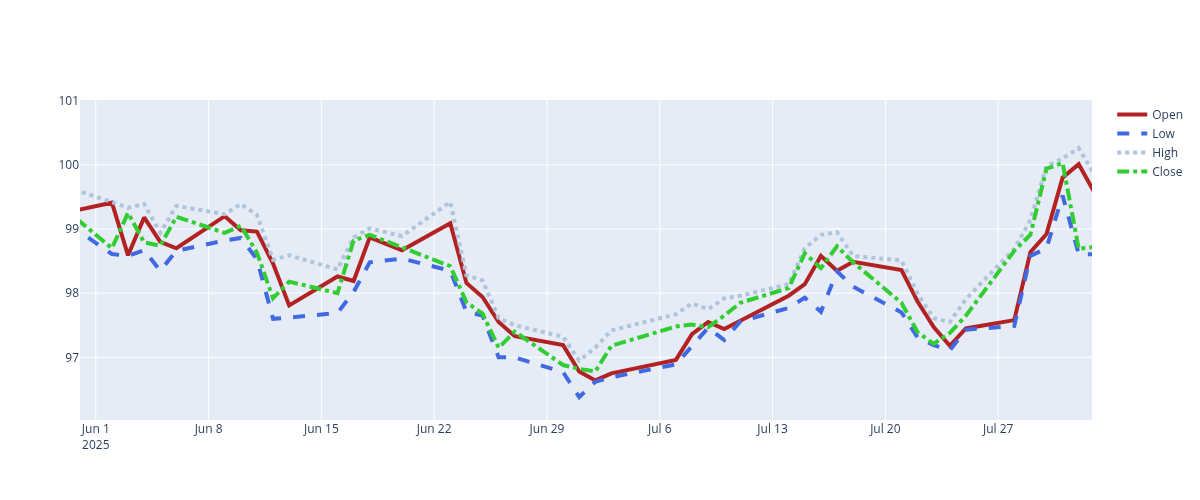

# Q5 - Is the value of Close predictable?
It is possible to predict the next day's Close value based on a day's Open, High, Low and Close values, with a certain accuracy. To do so, we must train a model which will try to approximate the market's behavior, thus allowing us to predict future values.

# Q6 - To split data in train-test, or not to split?
Splitting the data in train-test is a mandatory step towards training and assessing an ML model. However, we only need to split the data in past and future parts, not in a completely random fashion.

# Q7 - Createa dataset with Dataframes

In [4]:
date_df = df.copy()
date_df['Date'] = pd.to_datetime(df['Date'])
date_df = date_df.set_index(date_df['Date'])
date_df = date_df.sort_index()
train_df = date_df["2020-01-01":"2024-01-01"]
test_df = date_df["2024-01-01":]
train_df = train_df.drop(columns=['Date'])
test_df = test_df.drop(columns=['Date'])

# Q8 - Helper function to get a dataset in a format used for training a model

Δημιουργήστε συνάρτηση που θα παίρνει ως όρισμα ένα dataframe (είτε του train είτε του test), καθώς και μια παράμετρο  και θα επιστρέφει 2 numpy arrays: Inputs (x) και Targets (y), όπου x τα timeframes και y η τιμή close της επόμενης ημέρες. Τα timeframe είναι ένα σύνολο  διαδοχικών γραμμών. Για παράδειγμα αν N=3, τότε τα timeframes θα ήταν πίνακες 3x4, όπου 3 οι γραμμές και 4 τα χαρακτηριστικά open, high, low, close. Για N μέγεθος, το 1ο Timeframe θα περιλαμβάνει τις γραμμές x0:[0, N-1], το 2ο τις x1:[1:N], το 3ο x2:[2,N+1], κλπ. Για τα targets, το y0 θα ήταν το αντίστοιχο cN το y1 το cN+1, κλπ. Για τα Targets μπορείτε να χρησιμοποιήσετε την εντολή shift της pandas.

In [7]:
def convert(df: pd.DataFrame, N: int) -> np.array:
  target = df['Close']#.shift(periods=N)
  X = []
  Y = []
  # print('getting first pos\n', df.iloc[0:N, :])
  # print('getting target\n', df.iloc[N, -1])
  # print('getting 0 target:', target[N])
  for i in range(len(df)-N):
    x = df.iloc[i:i+N, :]
    y = target[i+N]
    x = np.array(x)
    x = x.flatten()
    X.append(x)
    Y.append(y)
  X = np.array(X)
  Y = np.array(Y)
  # print(X[0], Y[0])
  # print(X.shape, Y.shape)
  return X, Y

# convert(test_df, 3)

# Q9 - The effect of N
In order to predict next day's Close value, a small value of N might be more preferable, since the model will learn to predict more easily based on shorter periods of, where smaller deviations of the target value appear.

N should have a larger value if we aimed to predict the Close value on a larger time frame, since it would help the model make more accurate predictions without focusing on small-scale details.

#Q10 - Creating the dataset using numpy

In [8]:
N = 5
x_train, y_train = convert(train_df, N)
x_test, y_test = convert(test_df, N)
print(x_train.shape, y_train.shape)

(789, 20) (789,)


/tmp/ipython-input-1974869031.py:10: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



#Q11 - Train various models, then compare

In [15]:
scores = {}

# Linear Regression model
linear = LinearRegression().fit(x_train, y_train)
scores['linear'] = [linear.score(x_train, y_train),
                    linear.score(x_test, y_test)]
# Random Forest Regression model
rfr = RandomForestRegressor(random_state=0)
rfr.fit(x_train, y_train)
scores['random_forest'] = [rfr.score(x_train, y_train),
                            rfr.score(x_test, y_test)]
# Bagging Regression model
bagging = BaggingRegressor(estimator=LinearRegression(),
                        random_state=0).fit(x_train, y_train)
scores['bagging'] = [bagging.score(x_train, y_train),
                     bagging.score(x_test, y_test)]

# XG-Boost Regression model
xgb_model = xgb.XGBRegressor(n_jobs=1)
xgb_model.fit(x_train, y_train)
scores['xgb'] = [xgb_model.score(x_train, y_train),
                 xgb_model.score(x_test, y_test)]

# Stacking Regression model
stacking = StackingRegressor([('linear', LinearRegression()),
                              ('decision_tree', DecisionTreeRegressor())])
stacking.fit(x_train, y_train)
scores['stacking'] = [stacking.score(x_train, y_train),
                      stacking.score(x_test, y_test)]
